# 01 — Data Exploration

Explore both datasets: class distribution, speaker counts, and a side-by-side comparison of Mel-spectrogram vs MFCC features for the same audio file.

- **CREMA-D** — 7,442 files, 91 actors, 6 emotions
- **RAVDESS** — 1,056 speech files, 24 actors, 6 of 8 emotions used (calm and surprised excluded)

```bash
python data_loader.py
```

In [9]:
import sys
sys.path.insert(0, '..')  # allow imports from project root

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from feature_extraction import extract_mel, extract_mfcc

## CREMA-D — Dataset Statistics

In [10]:
df = pd.read_csv('../crema_metadata.csv')

print(f"Total samples : {len(df)}")
print(f"Unique actors : {df['actor_id'].nunique()}")
print(f"Emotions      : {sorted(df['emotion_name'].unique())}")
print()
print(df.groupby('emotion_name')['emotion_id'].count().rename('count').to_string())

Total samples : 7442
Unique actors : 91
Emotions      : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

emotion_name
angry      1271
disgust    1271
fear       1271
happy      1271
neutral    1087
sad        1271


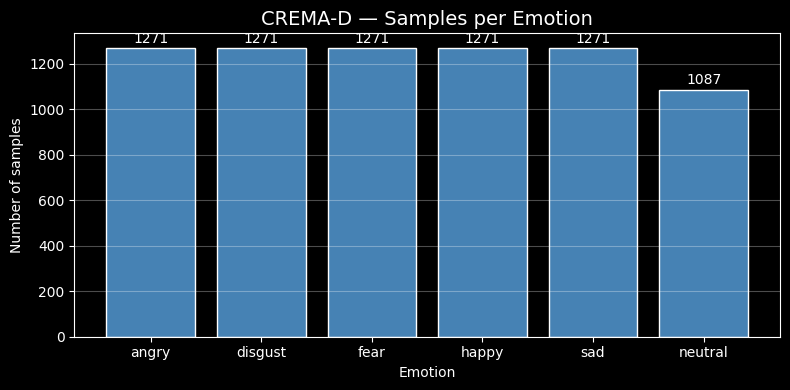

In [11]:
emotion_counts = df.groupby('emotion_name')['emotion_id'].count().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(emotion_counts.index, emotion_counts.values, color='steelblue', edgecolor='white')
plt.title('CREMA-D — Samples per Emotion', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Number of samples')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, emotion_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, str(val),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## CREMA-D — Mel-spectrogram vs MFCC

Both representations are extracted from the same audio file. The model input shape is **(1, 40, 200)** for both — 40 frequency bins × 200 time frames.

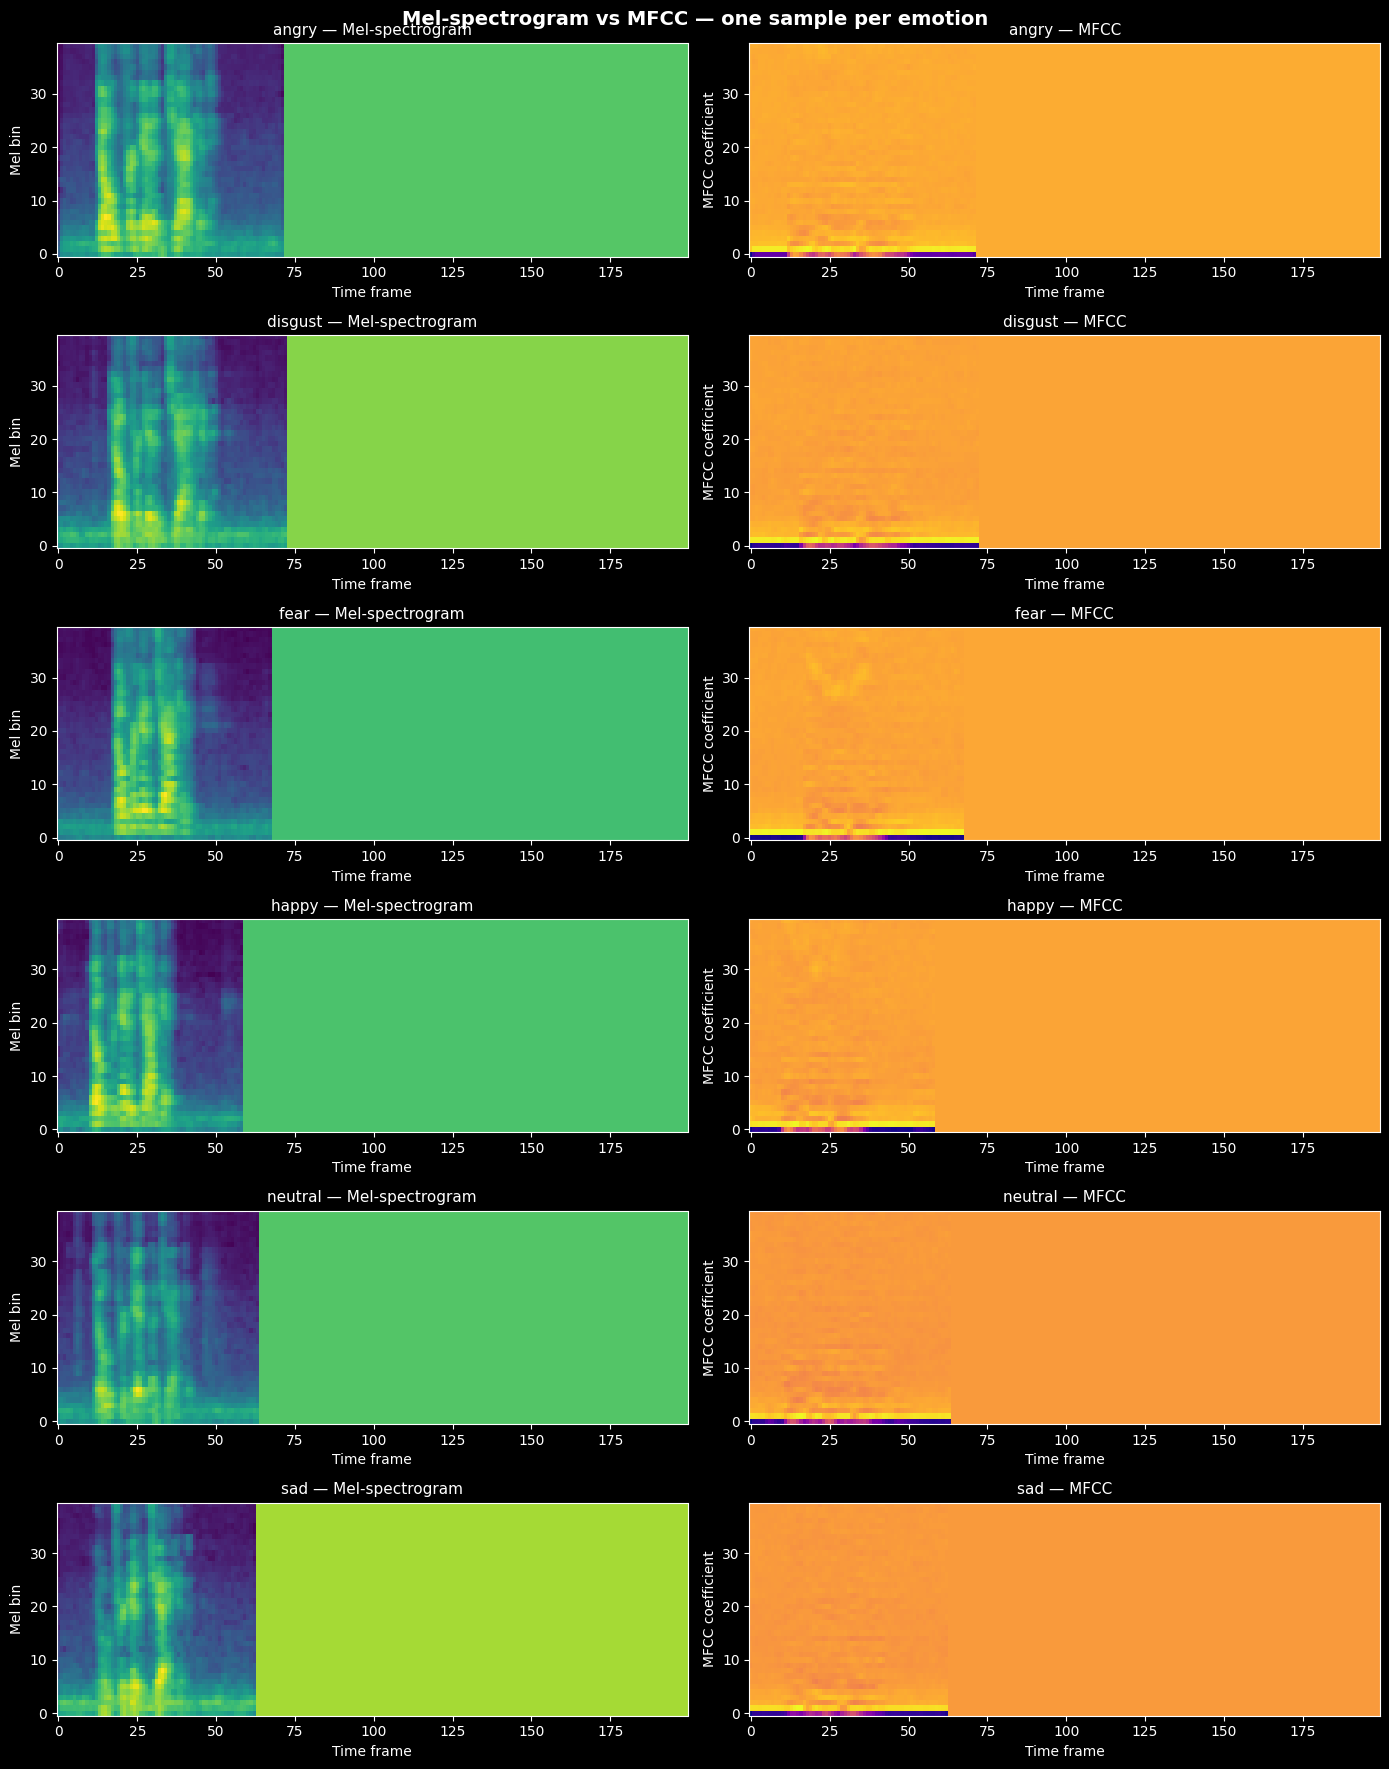

In [12]:
# Pick one sample per emotion for comparison
emotions = sorted(df['emotion_name'].unique())

fig, axes = plt.subplots(len(emotions), 2, figsize=(14, 3 * len(emotions)))

for i, emotion in enumerate(emotions):
    row = df[df['emotion_name'] == emotion].iloc[0]
    wav_path = row['file_path']

    mel  = extract_mel(f'../{wav_path}')
    mfcc = extract_mfcc(f'../{wav_path}')

    axes[i, 0].imshow(mel,  aspect='auto', origin='lower', cmap='viridis')
    axes[i, 0].set_title(f'{emotion} — Mel-spectrogram', fontsize=11)
    axes[i, 0].set_xlabel('Time frame')
    axes[i, 0].set_ylabel('Mel bin')

    axes[i, 1].imshow(mfcc, aspect='auto', origin='lower', cmap='plasma')
    axes[i, 1].set_title(f'{emotion} — MFCC', fontsize=11)
    axes[i, 1].set_xlabel('Time frame')
    axes[i, 1].set_ylabel('MFCC coefficient')

plt.suptitle('Mel-spectrogram vs MFCC — one sample per emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## RAVDESS — Dataset Statistics

RAVDESS uses numeric emotion codes. We keep 6 of the 8 emotions: neutral (01), happy (03), sad (04), angry (05), fearful (06), disgust (07). Calm (02) and surprised (08) are excluded to match CREMA-D's emotion set.

In [13]:
df_r = pd.read_csv('../ravdess_metadata.csv', dtype={'emotion_code': str})

print(f"Total samples : {len(df_r)}")
print(f"Unique actors : {df_r['actor_id'].nunique()}")
print(f"Emotions      : {sorted(df_r['emotion_name'].unique())}")
print()
print(df_r.groupby('emotion_name')['emotion_id'].count().rename('count').to_string())

Total samples : 1056
Unique actors : 24
Emotions      : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']

emotion_name
angry      192
disgust    192
fearful    192
happy      192
neutral     96
sad        192


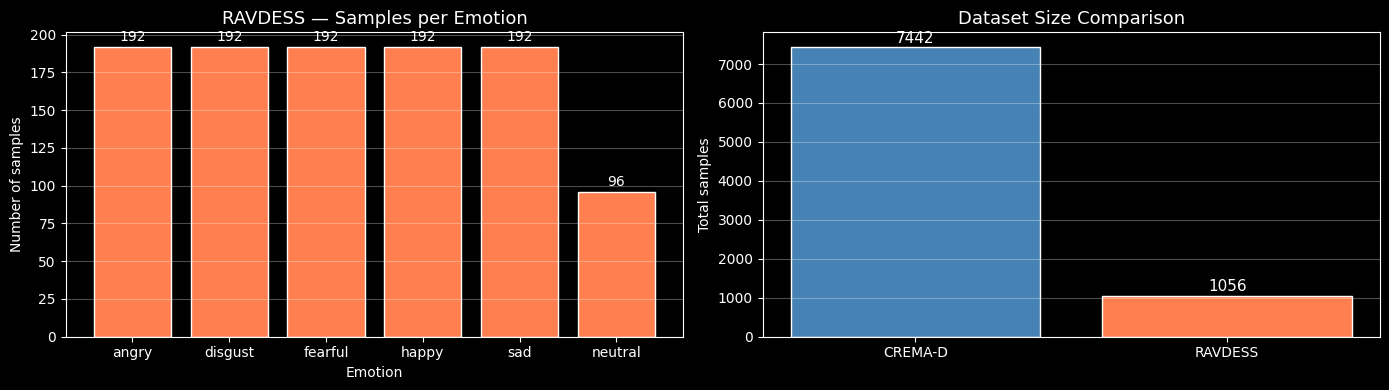

In [14]:
emotion_counts_r = df_r.groupby('emotion_name')['emotion_id'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RAVDESS class distribution
bars = axes[0].bar(emotion_counts_r.index, emotion_counts_r.values, color='coral', edgecolor='white')
axes[0].set_title('RAVDESS — Samples per Emotion', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of samples')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, emotion_counts_r.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
                 ha='center', va='bottom', fontsize=10)

# Dataset size comparison
datasets   = ['CREMA-D', 'RAVDESS']
totals     = [len(df), len(df_r)]
colors     = ['steelblue', 'coral']
bars2 = axes[1].bar(datasets, totals, color=colors, edgecolor='white')
axes[1].set_title('Dataset Size Comparison', fontsize=13)
axes[1].set_ylabel('Total samples')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, totals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, str(val),
                 ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## RAVDESS — Mel-spectrogram vs MFCC

Same comparison as CREMA-D above but on RAVDESS samples. RAVDESS is studio-recorded with professional actors, so spectrograms tend to look cleaner than CREMA-D (crowdsourced).

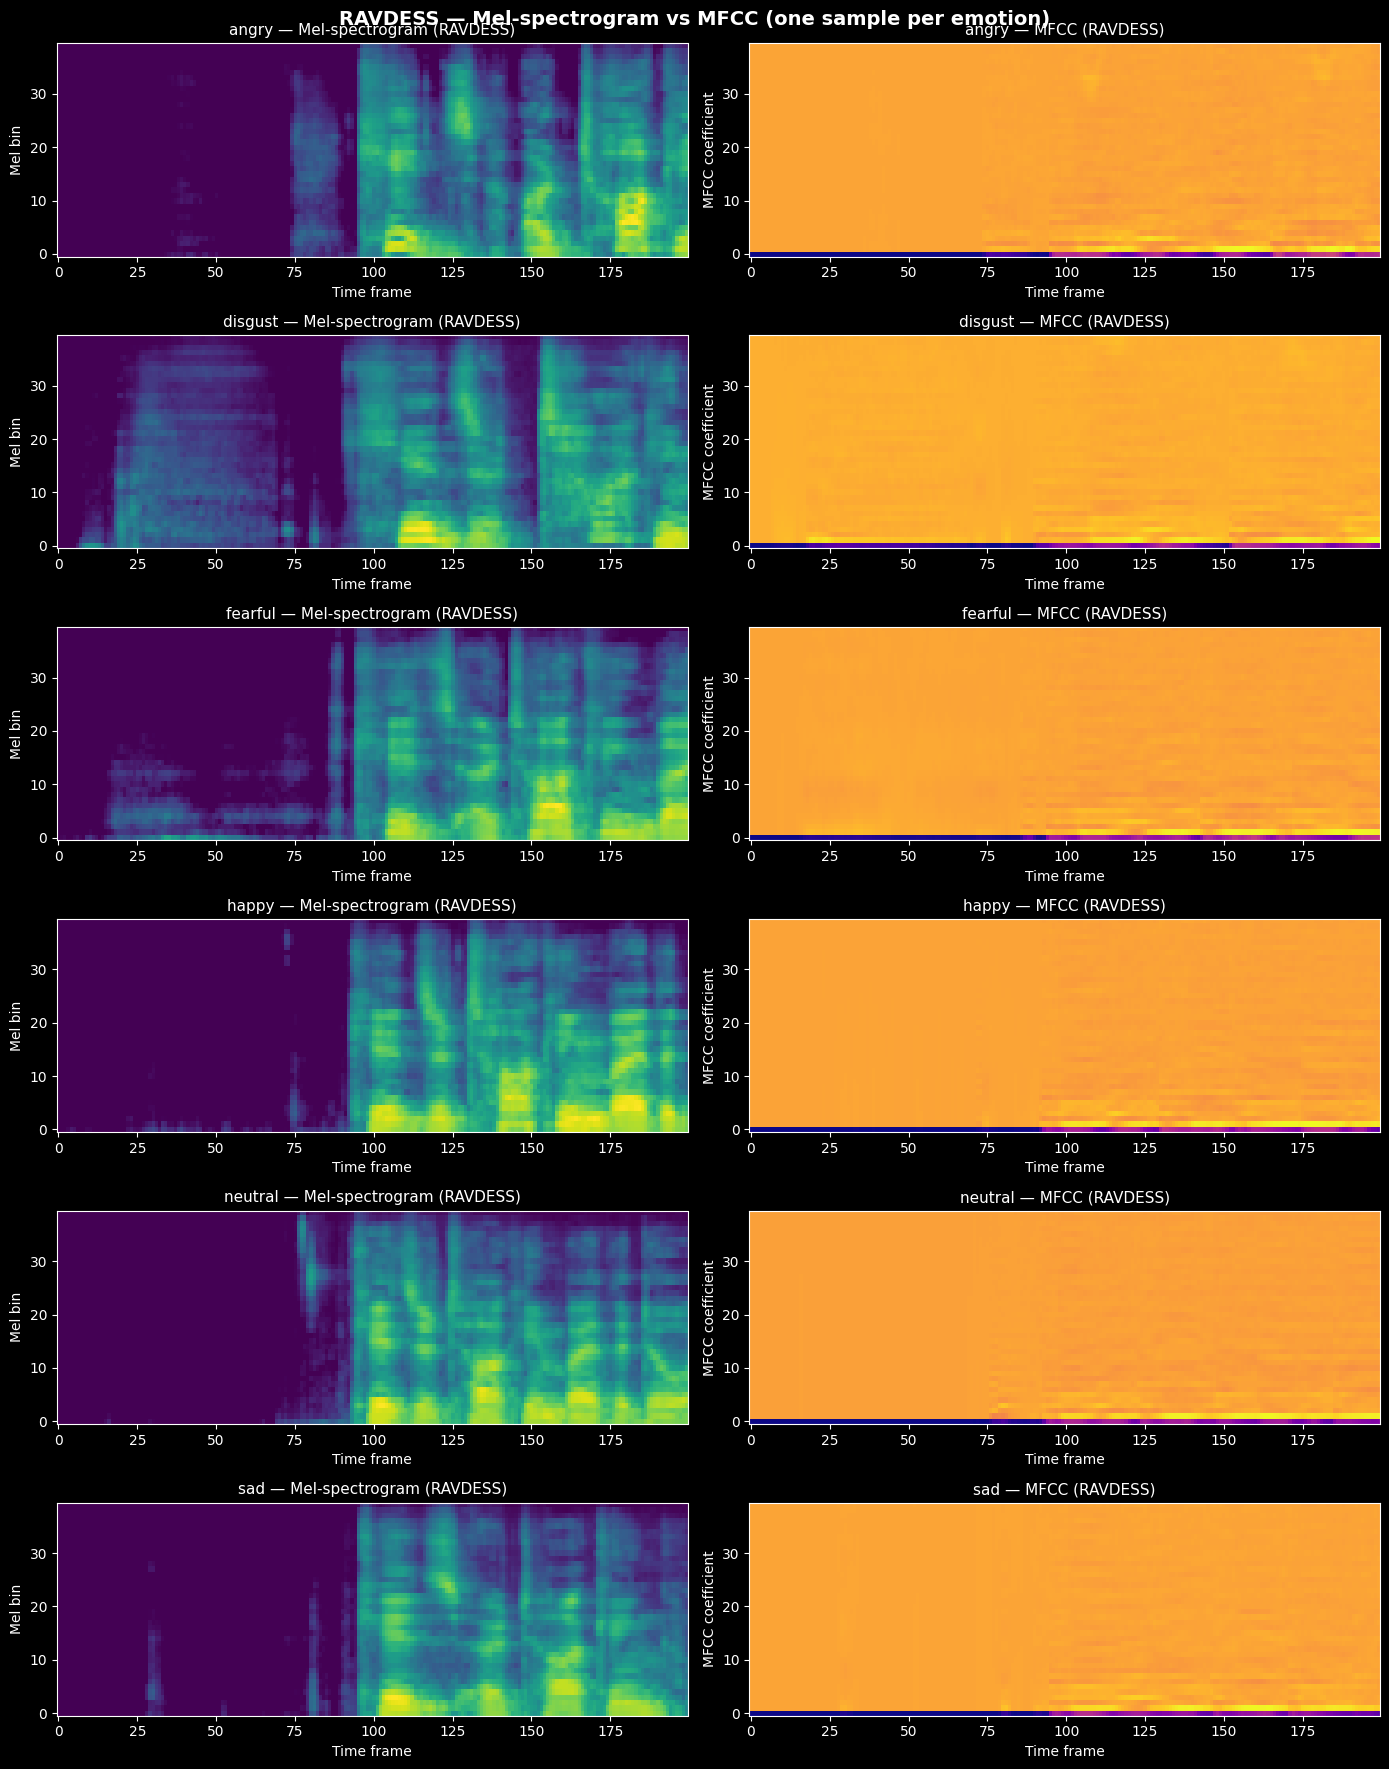

In [15]:
emotions_r = sorted(df_r['emotion_name'].unique())

fig, axes = plt.subplots(len(emotions_r), 2, figsize=(14, 3 * len(emotions_r)))

for i, emotion in enumerate(emotions_r):
    row = df_r[df_r['emotion_name'] == emotion].iloc[0]
    wav_path = row['file_path']

    mel  = extract_mel(f'../{wav_path}')
    mfcc = extract_mfcc(f'../{wav_path}')

    axes[i, 0].imshow(mel,  aspect='auto', origin='lower', cmap='viridis')
    axes[i, 0].set_title(f'{emotion} — Mel-spectrogram (RAVDESS)', fontsize=11)
    axes[i, 0].set_xlabel('Time frame')
    axes[i, 0].set_ylabel('Mel bin')

    axes[i, 1].imshow(mfcc, aspect='auto', origin='lower', cmap='plasma')
    axes[i, 1].set_title(f'{emotion} — MFCC (RAVDESS)', fontsize=11)
    axes[i, 1].set_xlabel('Time frame')
    axes[i, 1].set_ylabel('MFCC coefficient')

plt.suptitle('RAVDESS — Mel-spectrogram vs MFCC (one sample per emotion)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()